## Các biểu đồ trong bài báo cáo

In [3]:
# Đọc dữ liệu tuyển dụng AI và kiểm tra số lượng biến số
import pandas as pd

df = pd.read_csv("ai_jobs_market_2025_2026.csv")
df.shape

(1500, 25)

In [24]:
# Thống kê tổng quan bộ dữ liệu và Định dạng các biến
import pandas as pd

df = pd.read_csv("ai_jobs_market_2025_2026.csv")

print("===== THỐNG KÊ DATASET =====")
print("Số dòng:", df.shape[0])
print("Số cột:", df.shape[1])

numeric_cols = df.select_dtypes(include='number').columns
categorical_cols = df.select_dtypes(include=['object', 'string']).columns

print("\nBiến số (numeric) (", len(numeric_cols), "):")
for col in numeric_cols:
    print("-", col)

print("\nBiến phân loại (categorical) (", len(categorical_cols), "):")
for col in categorical_cols:
    print("-", col)

===== THỐNG KÊ DATASET =====
Số dòng: 1500
Số cột: 25

Biến số (numeric) ( 13 ):
- years_of_experience
- annual_salary_usd
- salary_min_usd
- salary_max_usd
- ai_salary_premium_pct
- demand_score
- demand_growth_yoy_pct
- benefits_score_10
- posting_year
- posting_month
- is_senior
- is_remote_friendly
- is_llm_role

Biến phân loại (categorical) ( 12 ):
- job_id
- job_title
- job_category
- experience_level
- education_required
- city
- country
- remote_work
- company_size
- industry
- required_skills
- salary_tier


In [4]:
# Đánh giá chất lượng dữ liệu và xác định các giá trị khuyết thiếu
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   job_id                 1500 non-null   str    
 1   job_title              1500 non-null   str    
 2   job_category           1500 non-null   str    
 3   experience_level       1500 non-null   str    
 4   years_of_experience    1500 non-null   int64  
 5   education_required     1500 non-null   str    
 6   annual_salary_usd      1500 non-null   float64
 7   salary_min_usd         1500 non-null   int64  
 8   salary_max_usd         1500 non-null   int64  
 9   city                   1500 non-null   str    
 10  country                1500 non-null   str    
 11  remote_work            1500 non-null   str    
 12  company_size           1500 non-null   str    
 13  industry               1500 non-null   str    
 14  required_skills        1500 non-null   str    
 15  ai_salary_premi

In [5]:
# Thống kê và điếm dữ liệu khuyết thiếu
df.isnull().sum()

job_id                   0
job_title                0
job_category             0
experience_level         0
years_of_experience      0
education_required       0
annual_salary_usd        0
salary_min_usd           0
salary_max_usd           0
city                     0
country                  0
remote_work              0
company_size             0
industry                 0
required_skills          0
ai_salary_premium_pct    0
demand_score             0
demand_growth_yoy_pct    0
benefits_score_10        0
posting_year             0
posting_month            0
is_senior                0
is_remote_friendly       0
is_llm_role              0
salary_tier              0
dtype: int64

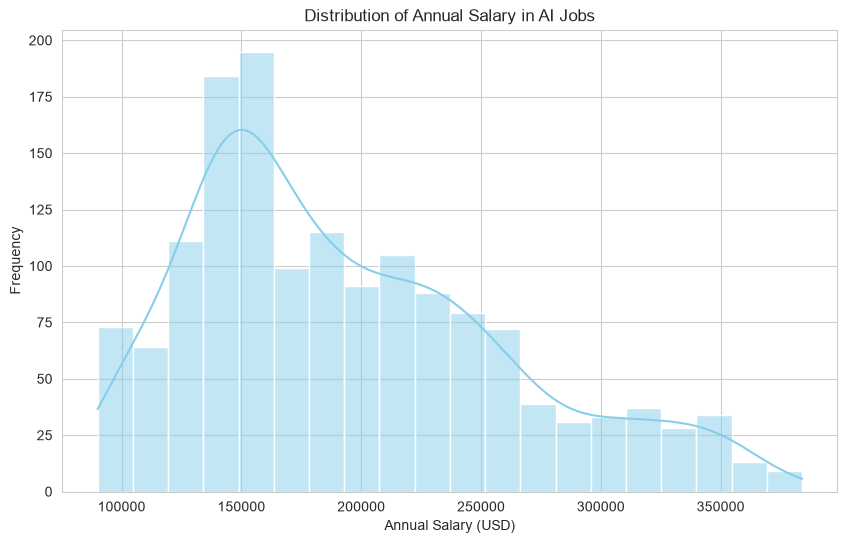

In [25]:
# Biểu đồ phân phối mức lương năm ngành AI giai đoạn 2025–2026
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("ai_jobs_market_2025_2026.csv")

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='annual_salary_usd',
    bins=20,
    kde=True,
    color='skyblue'
)

plt.title('Distribution of Annual Salary in AI Jobs')
plt.xlabel('Annual Salary (USD)')
plt.ylabel('Frequency')

plt.show()

In [6]:
# Phân đoạn dữ liệu tiền lương và Xác định khoảng thu nhập phổ biến nhất
salary_bins = pd.cut(df['annual_salary_usd'], bins=10)

freq = salary_bins.value_counts().sort_index()

print(freq)

print("\nKhoảng lương xuất hiện nhiều nhất:")
print(freq.idxmax())

annual_salary_usd
(89706.0, 119400.0]     137
(119400.0, 148800.0]    295
(148800.0, 178200.0]    294
(178200.0, 207600.0]    206
(207600.0, 237000.0]    198
(237000.0, 266400.0]    146
(266400.0, 295800.0]     70
(295800.0, 325200.0]     70
(325200.0, 354600.0]     62
(354600.0, 384000.0]     22
Name: count, dtype: int64

Khoảng lương xuất hiện nhiều nhất:
(119400.0, 148800.0]


In [7]:
# Tóm tắt các chỉ số thống kê cốt lõi của biến mức lương ngành AI
print(df['annual_salary_usd'].describe())

count      1500.000000
mean     194892.000000
std       66506.822013
min       90000.000000
25%      144750.000000
50%      180000.000000
75%      236250.000000
max      384000.000000
Name: annual_salary_usd, dtype: float64


/var/folders/_b/03mc_vt90tl0hq6h4c8vdbsm0000gn/T/ipykernel_2519/2193322428.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


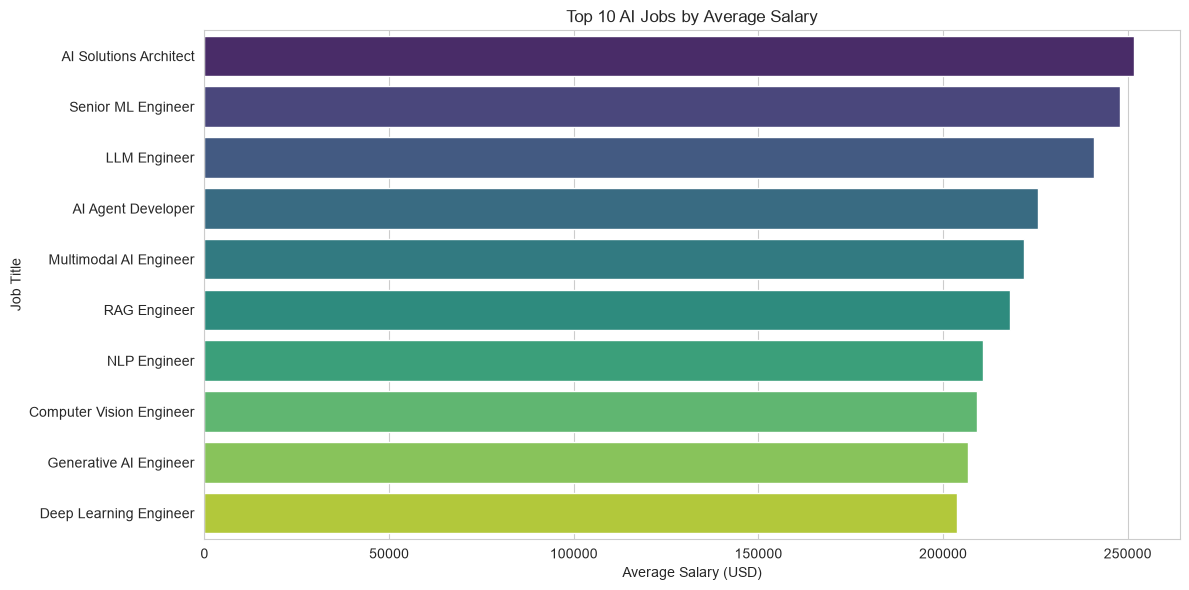

job_title
AI Solutions Architect      251576.923077
Senior ML Engineer          247953.125000
LLM Engineer                240960.000000
AI Agent Developer          225649.122807
Multimodal AI Engineer      221791.044776
RAG Engineer                218226.415094
NLP Engineer                210854.545455
Computer Vision Engineer    209173.913043
Generative AI Engineer      206760.563380
Deep Learning Engineer      203810.344828
Name: annual_salary_usd, dtype: float64


In [10]:
# Trực quan hóa Top 10 vị trí việc làm AI có thu nhập bình quân cao nhất
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("ai_jobs_market_2025_2026.csv")

# Tính lương trung bình theo vị trí
salary_by_job = (
    df.groupby("job_title")["annual_salary_usd"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=salary_by_job.values,
    y=salary_by_job.index,
    palette="viridis"
)

plt.title("Top 10 AI Jobs by Average Salary")
plt.xlabel("Average Salary (USD)")
plt.ylabel("Job Title")

plt.tight_layout()
plt.show()

print(salary_by_job)

/var/folders/_b/03mc_vt90tl0hq6h4c8vdbsm0000gn/T/ipykernel_2519/741009754.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


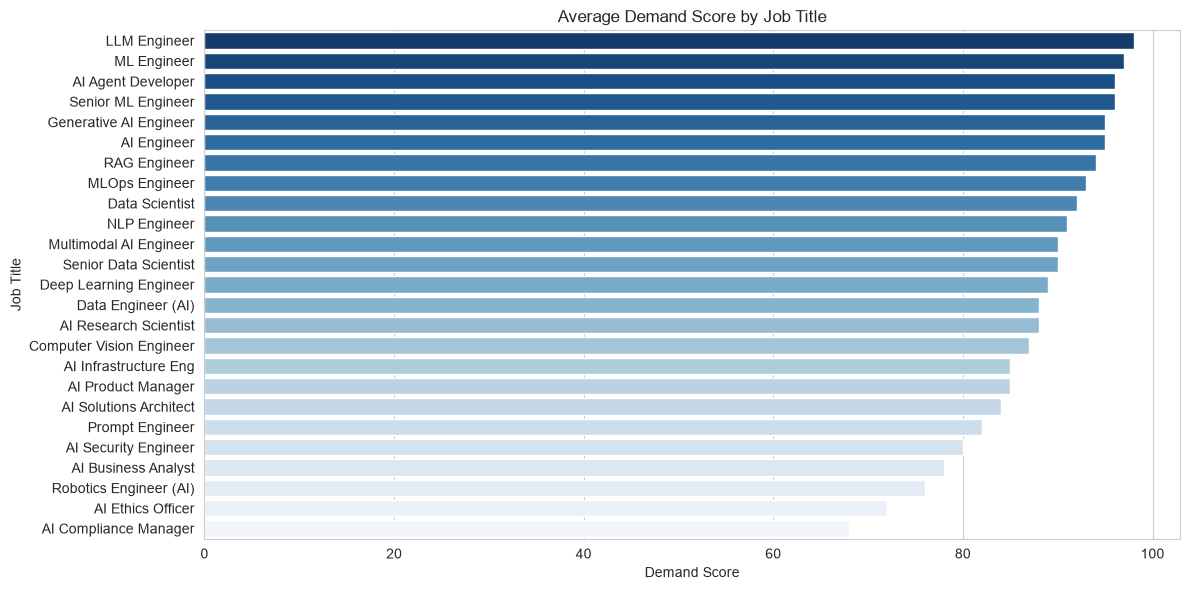

job_title
LLM Engineer              98.0
ML Engineer               97.0
AI Agent Developer        96.0
Senior ML Engineer        96.0
Generative AI Engineer    95.0
AI Engineer               95.0
RAG Engineer              94.0
MLOps Engineer            93.0
Data Scientist            92.0
NLP Engineer              91.0
Name: demand_score, dtype: float64


In [9]:
# Trực quan hóa thứ hạng nhu cầu thị trường lao động đối với các vai trò chuyên môn AI
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("ai_jobs_market_2025_2026.csv")

# Demand score trung bình theo nghề
demand_job = (
    df.groupby("job_title")["demand_score"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=demand_job.values,
    y=demand_job.index,
    palette="Blues_r"
)

plt.title("Average Demand Score by Job Title")
plt.xlabel("Demand Score")
plt.ylabel("Job Title")

plt.tight_layout()
plt.show()

print(demand_job.head(10))

              Skill  Frequency
2            Python        942
4               SQL        452
3             Cloud        429
5        Leadership        380
21    Communication        378
39         Research        376
14            Agile        351
20       Statistics        350
41            Linux        320
24  Problem Solving        314
51          PyTorch        302
27              Git        295
13      Fine-tuning        164
48             LLMs        125
44       Kubernetes        123


/var/folders/_b/03mc_vt90tl0hq6h4c8vdbsm0000gn/T/ipykernel_2519/300767325.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


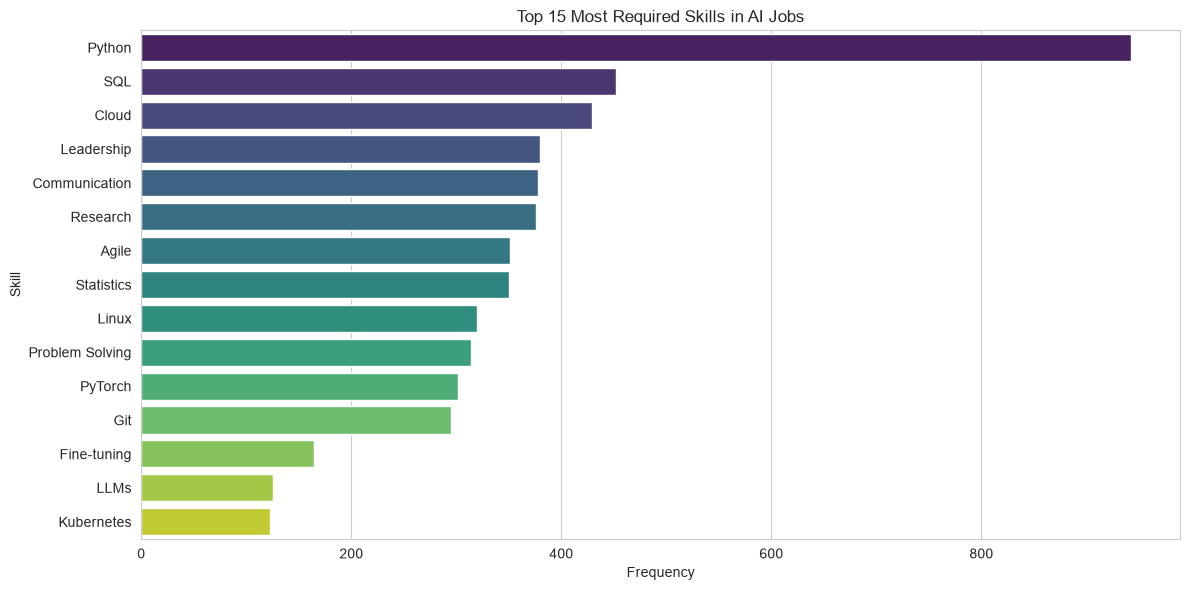

In [8]:
# Trực quan hóa Top 15 kỹ năng kỹ thuật có nhu cầu tuyển dụng cao nhất
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

df = pd.read_csv("ai_jobs_market_2025_2026.csv")

# Tách tất cả skills
all_skills = []

for skills in df["required_skills"]:
    all_skills.extend(skills.split("|"))

# Đếm tần suất
skill_counts = Counter(all_skills)

# Top 15 kỹ năng phổ biến nhất
top_skills = pd.DataFrame(
    skill_counts.items(),
    columns=["Skill", "Frequency"]
).sort_values(
    by="Frequency",
    ascending=False
).head(15)

print(top_skills)

# Vẽ biểu đồ
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_skills,
    x="Frequency",
    y="Skill",
    palette="viridis"
)

plt.title("Top 15 Most Required Skills in AI Jobs")
plt.xlabel("Frequency")
plt.ylabel("Skill")

plt.tight_layout()
plt.show()

In [12]:
# Thống kê giá trị trung bình nhóm và Xác định tỷ lệ tăng trưởng lương của vai trò LLM
salary_compare = df.groupby("is_llm_role")["annual_salary_usd"].mean()

print(salary_compare)

llm_salary = salary_compare[1]
non_llm_salary = salary_compare[0]

increase_pct = (
    (llm_salary - non_llm_salary)
    / non_llm_salary
) * 100

print(f"LLM salary premium: {increase_pct:.2f}%")

is_llm_role
0    191308.610401
1    207746.177370
Name: annual_salary_usd, dtype: float64
LLM salary premium: 8.59%


In [13]:
# Thực hiện kiểm định T-test độc lập đối với giả thuyết về sự khác biệt thu nhập nhóm LLM
from scipy.stats import ttest_ind

llm_salary = df[df['is_llm_role']==1]['annual_salary_usd']
non_llm_salary = df[df['is_llm_role']==0]['annual_salary_usd']

t_stat, p_value = ttest_ind(llm_salary, non_llm_salary)

print("T-statistic =", t_stat)
print("P-value =", p_value)

T-statistic = 3.9717177186133754
P-value = 7.47427277811813e-05


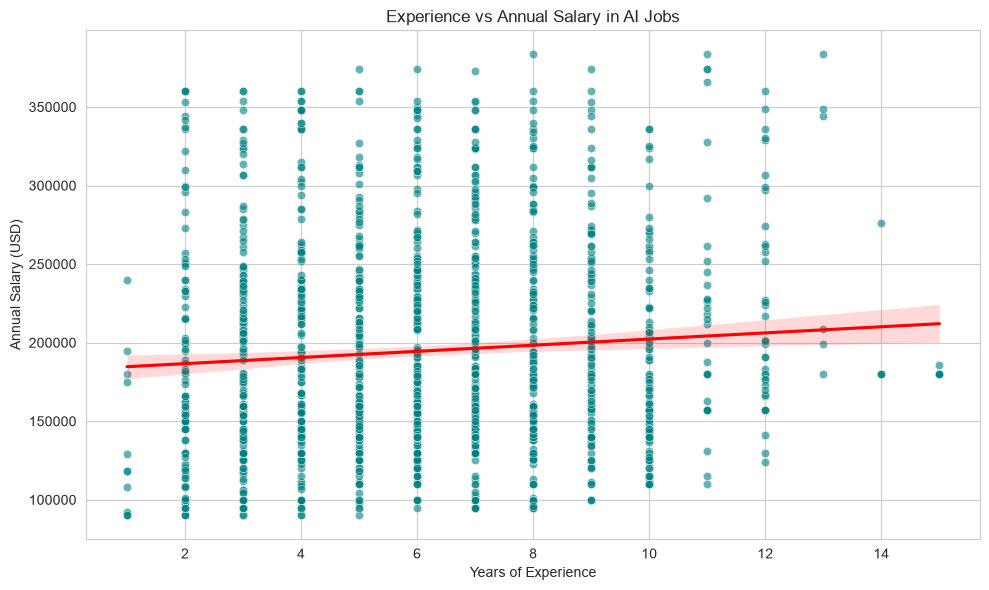

In [14]:
# Phân tích mối quan hệ tương quan tuyến tính giữa số năm kinh nghiệm và mức lương năm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("ai_jobs_market_2025_2026.csv")

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="years_of_experience",
    y="annual_salary_usd",
    alpha=0.6,
    color="teal"
)

sns.regplot(
    data=df,
    x="years_of_experience",
    y="annual_salary_usd",
    scatter=False,
    color="red"
)

plt.title("Experience vs Annual Salary in AI Jobs")
plt.xlabel("Years of Experience")
plt.ylabel("Annual Salary (USD)")

plt.tight_layout()
plt.show()

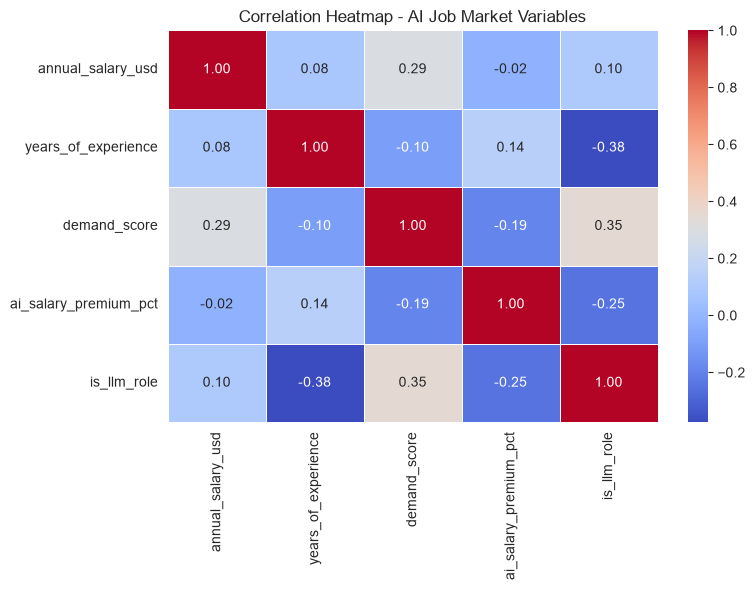

annual_salary_usd        1.000000
demand_score             0.291800
is_llm_role              0.102082
years_of_experience      0.078643
ai_salary_premium_pct   -0.019829
Name: annual_salary_usd, dtype: float64


In [15]:
# Trực quan hóa ma trận tương quan (Correlation Matrix) bằng biểu đồ nhiệt Heatmap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("ai_jobs_market_2025_2026.csv")

# Chọn các biến quan trọng
corr_cols = [
    "annual_salary_usd",
    "years_of_experience",
    "demand_score",
    "ai_salary_premium_pct",
    "is_llm_role"
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap - AI Job Market Variables")

plt.tight_layout()
plt.show()

print(corr_matrix["annual_salary_usd"].sort_values(ascending=False))

In [16]:
# Đo lường hệ số tương quan tuyến tính giữa các biến độc lập với biến mục tiêu tiền lương
df[corr_cols].corr()["annual_salary_usd"]

annual_salary_usd        1.000000
years_of_experience      0.078643
demand_score             0.291800
ai_salary_premium_pct   -0.019829
is_llm_role              0.102082
Name: annual_salary_usd, dtype: float64

In [17]:
# Thực hiện kiểm định phân tích phương sai (ANOVA) đối với các nhân tố định tính tác động lên tiền lương
import pandas as pd
from scipy.stats import f_oneway

df = pd.read_csv("ai_jobs_market_2025_2026.csv")

# 1. ANOVA theo job_title
groups_job = [
    df[df["job_title"] == x]["annual_salary_usd"]
    for x in df["job_title"].unique()
]

anova_job = f_oneway(*groups_job)

# 2. ANOVA theo education
groups_edu = [
    df[df["education_required"] == x]["annual_salary_usd"]
    for x in df["education_required"].unique()
]

anova_edu = f_oneway(*groups_edu)

# 3. ANOVA theo company_size
groups_company = [
    df[df["company_size"] == x]["annual_salary_usd"]
    for x in df["company_size"].unique()
]

anova_company = f_oneway(*groups_company)

# KẾT QUẢ
print("ANOVA job_title p-value:", anova_job.pvalue)
print("ANOVA education_required p-value:", anova_edu.pvalue)
print("ANOVA company_size p-value:", anova_company.pvalue)

ANOVA job_title p-value: 2.198975801776173e-62
ANOVA education_required p-value: 7.0813599062581815e-12
ANOVA company_size p-value: 3.446544813289725e-44


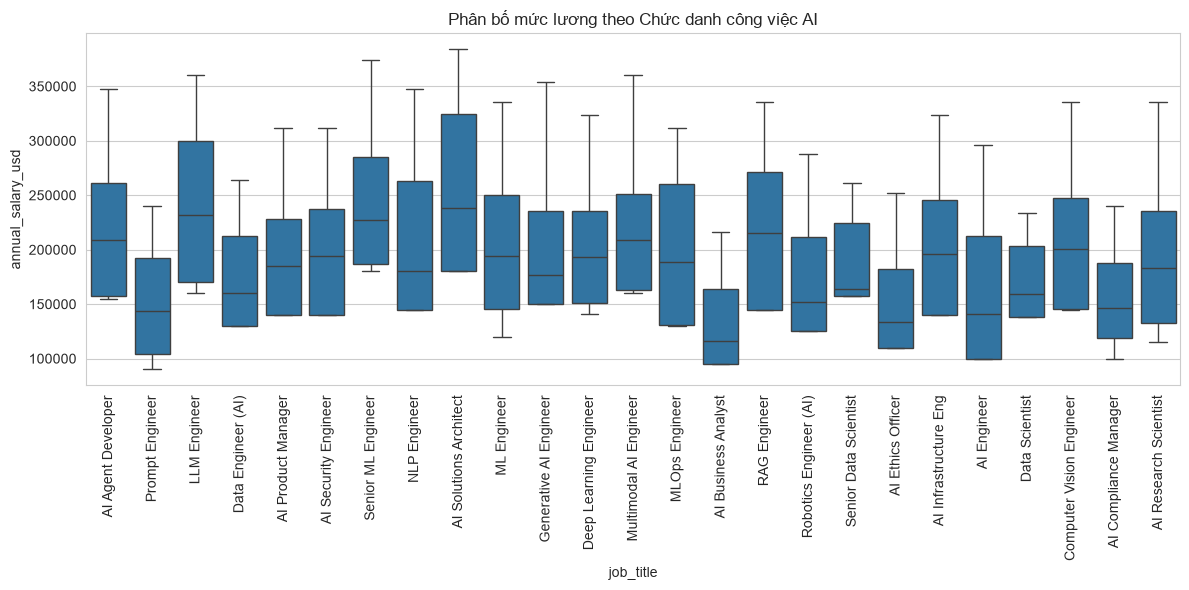

In [18]:
# Khảo sát sự phân hóa thu nhập theo danh mục chức danh công việc bằng biểu đồ hộp (Boxplot)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="job_title",
    y="annual_salary_usd"
)

plt.xticks(rotation=90)
plt.title("Phân bố mức lương theo Chức danh công việc AI")

plt.tight_layout()
plt.show()

In [20]:
# Thiết lập phương trình hồi quy đa biến và Đánh giá các chỉ số kiểm định sai số mô hình ($R^2, MSE)
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

df = pd.read_csv("ai_jobs_market_2025_2026.csv")

# Features
X = df[[
    "years_of_experience",
    "demand_score",
    "ai_salary_premium_pct"
]]

# Target
y = df["annual_salary_usd"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R2 Score:", r2)
print("MSE:", mse)

R2 Score: 0.05650142352815812
MSE: 3867381568.127559


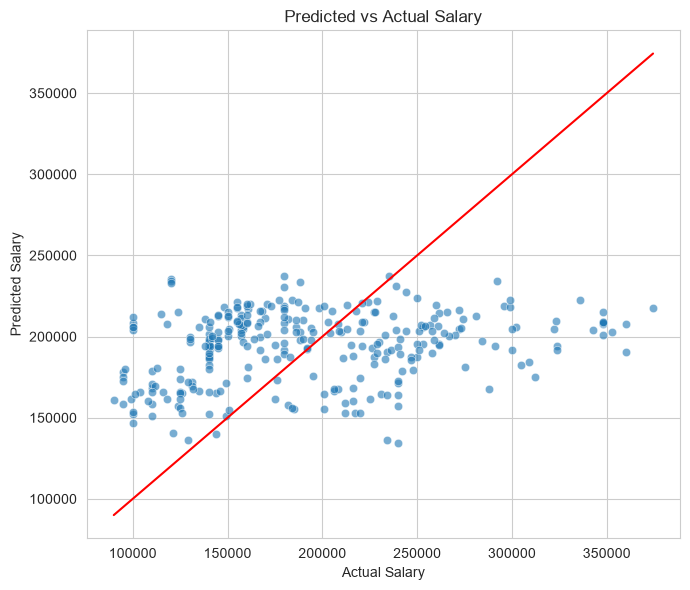

In [21]:
# Biểu đồ chẩn đoán sai số mô hình hồi quy (Actual vs. Predicted Plot)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,6))

sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.title("Predicted vs Actual Salary")
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")

plt.tight_layout()
plt.show()

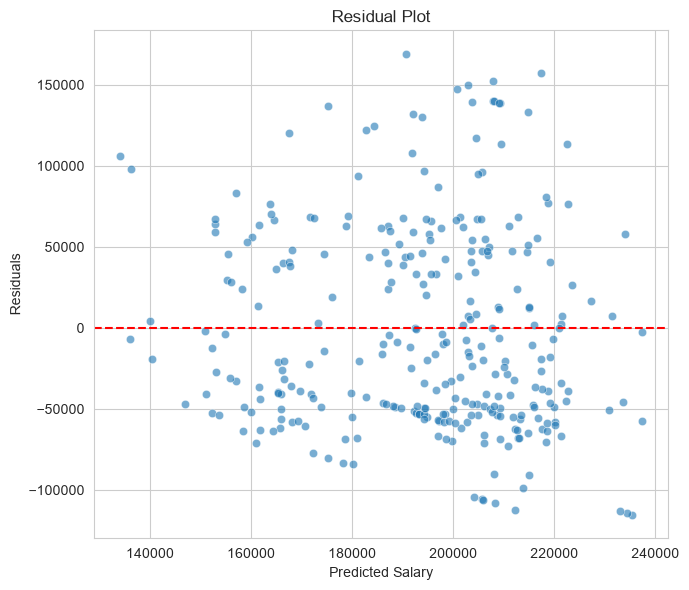

In [22]:
# Biểu đồ phần dư (Residual Plot) trong chẩn đoán khuyết tật mô hình tiền lương
residuals = y_test - y_pred

plt.figure(figsize=(7,6))

sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)

plt.axhline(y=0, color='red', linestyle='--')

plt.title("Residual Plot")
plt.xlabel("Predicted Salary")
plt.ylabel("Residuals")

plt.tight_layout()
plt.show()